In [1]:
import pandapower as pp
import pandapower.topology as top
import networkx as nx
import random
from gridfm_datakit.network import load_net_from_file, load_net_from_pglib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import random
import seaborn as sns
import numpy as np
from collections import Counter
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable

In [2]:
#net = load_net_from_file("gridfm_datakit/grids/Texas2k_case1_2016summerpeak.m")
net = load_net_from_pglib("case78484_epigrids")

# Create a networkx graph from the pandapower network
G = top.create_nxgraph(net, include_switches=False, multi=False)

# List of all bus indices
buses = list(G.nodes())

# Set of Slack bus indices
slack_buses = set(net.ext_grid['bus'].values)

In [3]:
net

This pandapower network includes the following parameter tables:
   - bus (78484 elements)
   - load (56504 elements)
   - sgen (4817 elements)
   - gen (2055 elements)
   - shunt (13 elements)
   - ext_grid (1 element)
   - line (88427 elements)
   - trafo (37719 elements)
   - poly_cost (6873 elements)

In [4]:
# pos = nx.spring_layout(G, seed=42)

# plt.figure(figsize=(20, 20))
# nx.draw(G, pos, node_size=20, edge_color='gray', with_labels=False)
# plt.title("Full Network")
# plt.show()

In [5]:
def random_walk_step(G, current_node):
    """Perform one step of a normal random walk on graph G."""
    neighbors = list(G.neighbors(current_node))
    if not neighbors:
        return current_node  # No move if no neighbors
    return random.choice(neighbors)

def mh_random_walk_step(G, current_node):
    """Perform one step of a Metropolis-Hastings random walk on graph G."""
    neighbors = list(G.neighbors(current_node))
    if not neighbors:
        return current_node  # No move if no neighbors
    
    candidate = random.choice(neighbors)
    deg_current = G.degree[current_node]
    deg_candidate = G.degree[candidate]
    
    # Acceptance probability min(1, degree_current / degree_candidate)
    acceptance_prob = deg_current / deg_candidate
    
    if random.random() < acceptance_prob:
        return candidate
    else:
        return current_node

In [6]:
# Parameters
num_walks = 10000
walk_length = 300
use_mh = True

In [7]:
# Assuming G (networkx graph), buses, slack_buses are defined
visit_counter = Counter()


for _ in range(num_walks):
    # Start at a random non-slack node
    while True:
        start_node = random.choice(buses)
        if start_node not in slack_buses:
            break

    current_node = start_node
    walk = [current_node]
    current_walk_length = random.randint(1, 1000)
    for _ in range(current_walk_length - 1):
        if use_mh:
            current_node = mh_random_walk_step(G, current_node)
        else:
            current_node = random_walk_step(G, current_node)
        walk.append(current_node)

    # Count all visits (MH allows revisits)
    visit_counter.update(walk)

# Normalize visit counts
total_visits = sum(visit_counter.values())
visit_freq = {node: count / total_visits for node, count in visit_counter.items()}

# Prepare data for plotting
node_degrees = dict(G.degree())
visit_data = [(node, node_degrees[node], visit_counter[node]) for node in G.nodes if node in visit_counter]

nodes, degrees, visits = zip(*visit_data)

c:\Users\MatteoMazzonelli\Desktop\GridFM_LFE\gridfm-datakit\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\MatteoMazzonelli\AppData\Local\Temp\ipykernel_33008\319805704.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("viridis")


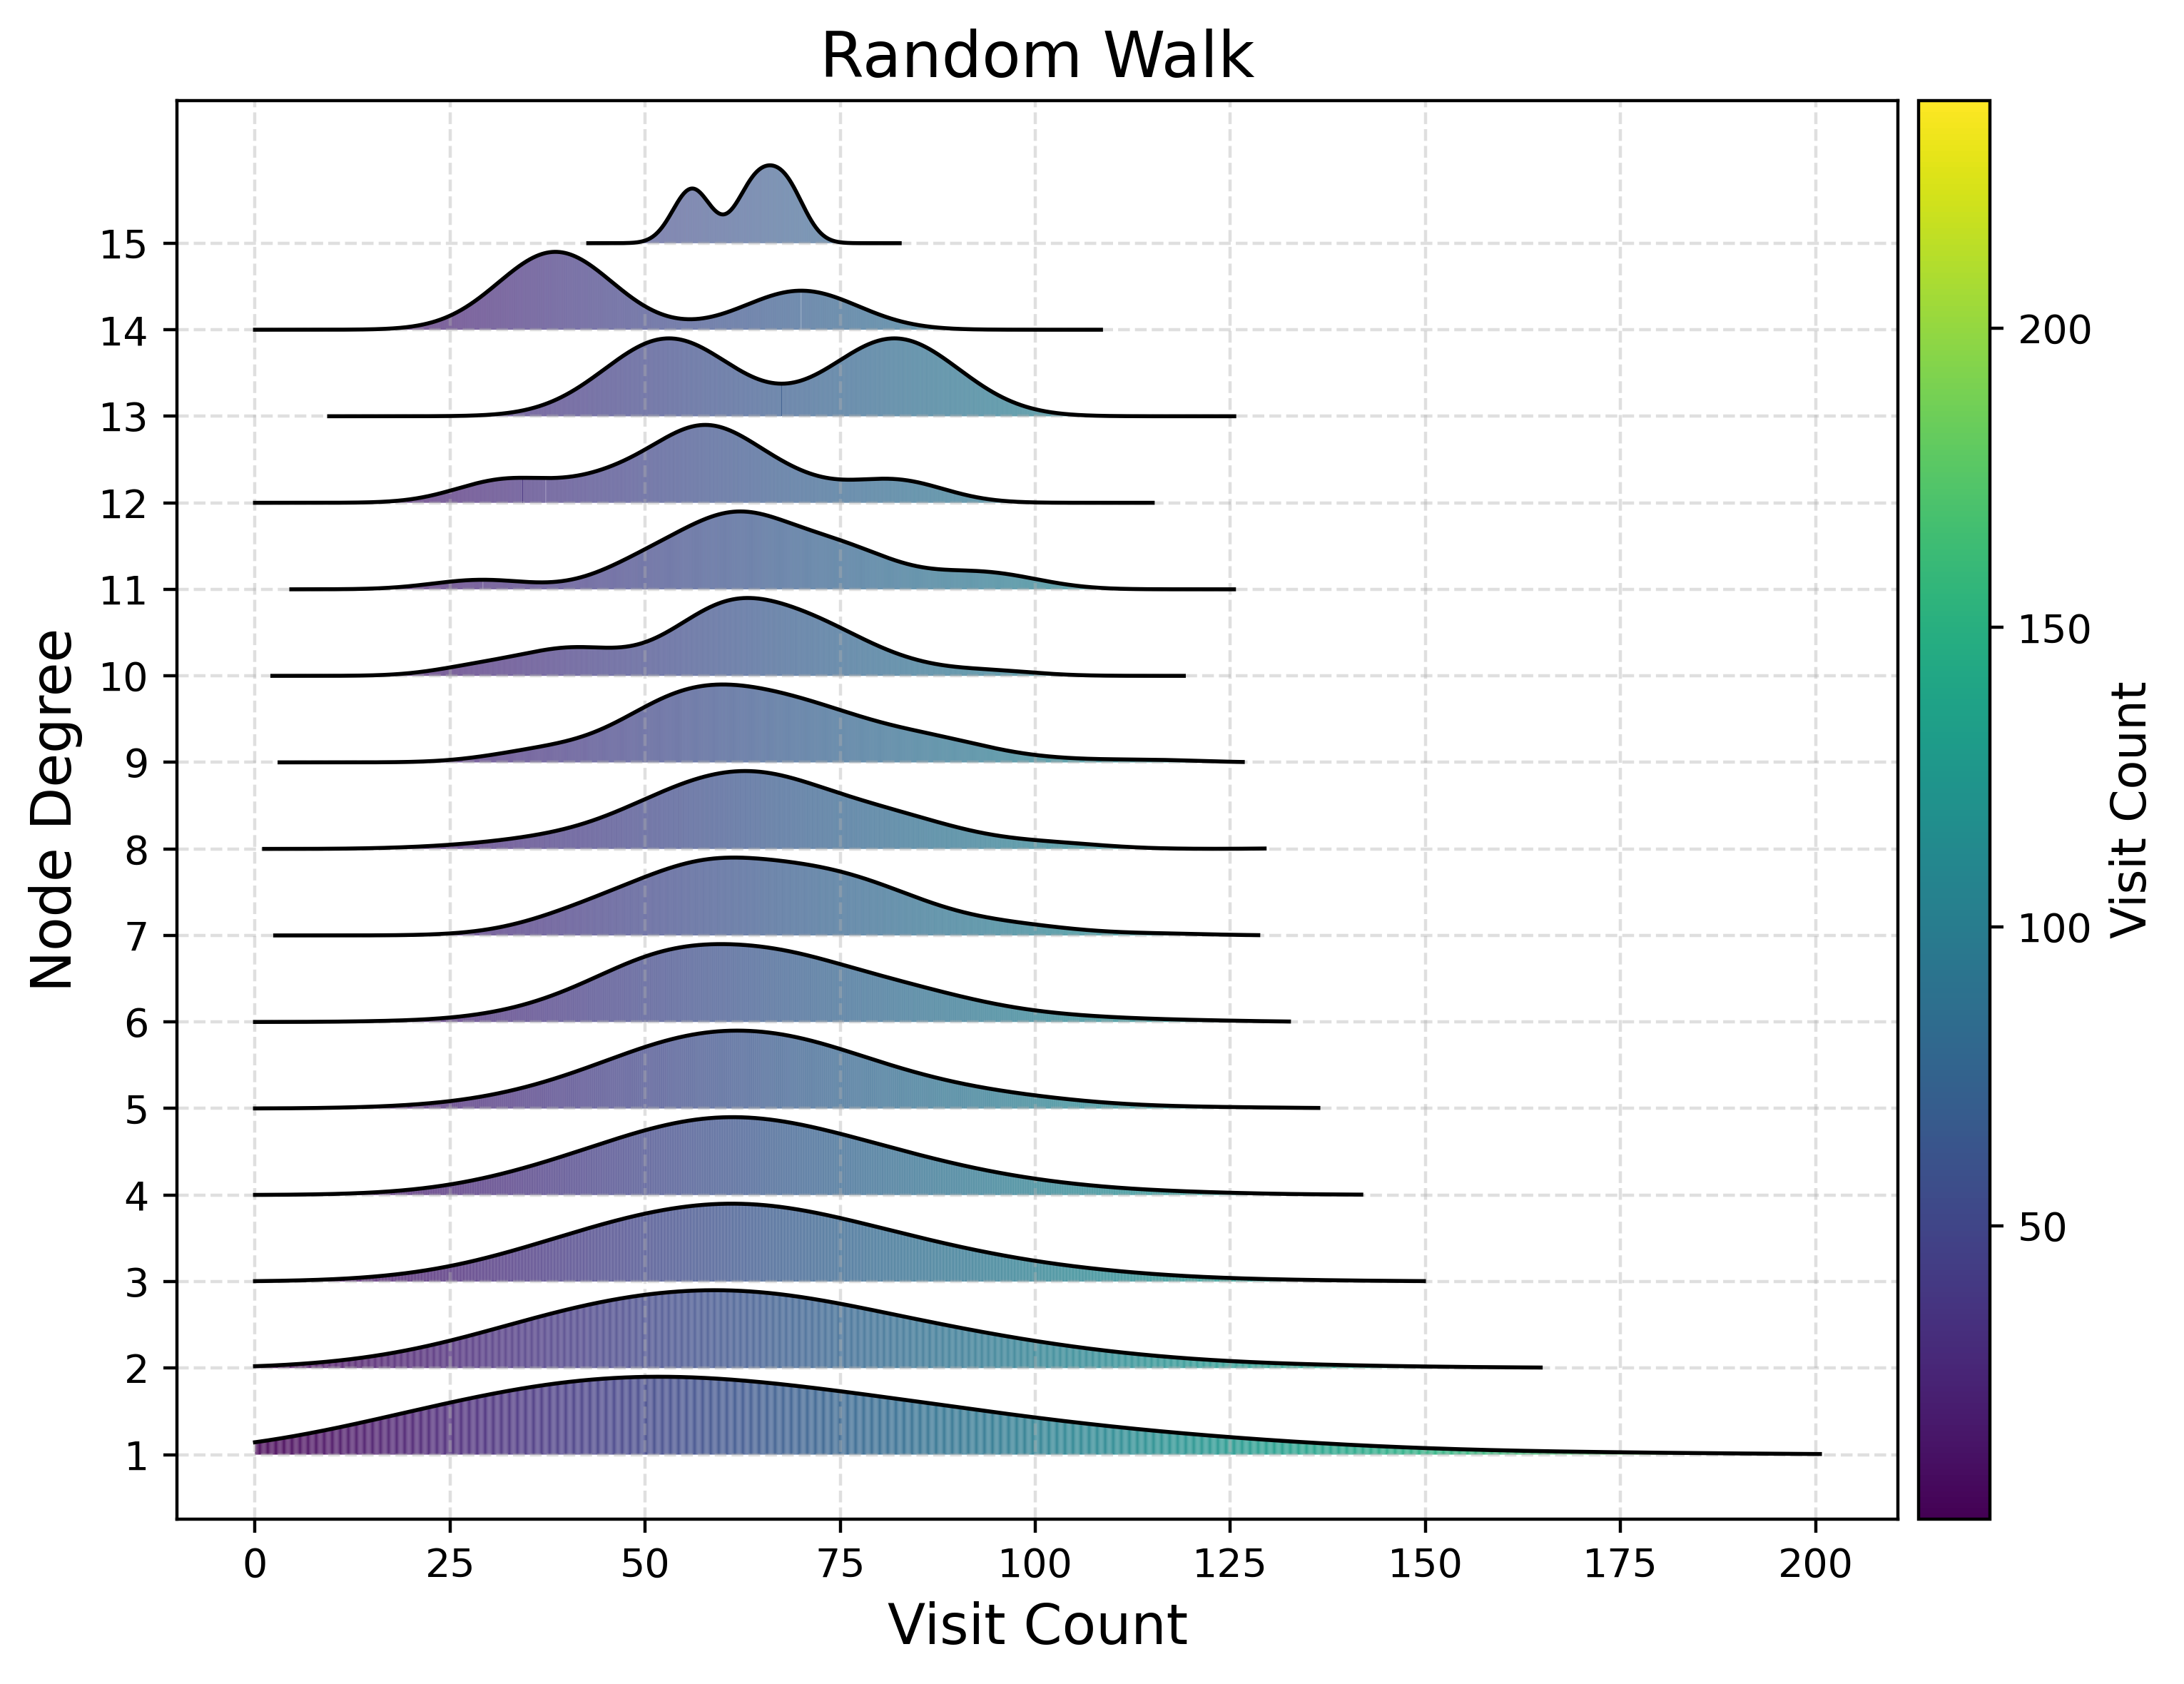

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from matplotlib.collections import PolyCollection
from scipy.stats import gaussian_kde

# Your DataFrame
df = pd.DataFrame({
    "Node": nodes,
    "Degree": degrees,
    "Visits": visits
})

# Unique degrees
unique_degrees = sorted(df["Degree"].unique())

# Set up figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=400)

# Color gradient setup
cmap = get_cmap("viridis")
global_min = df["Visits"].min()
global_max = df["Visits"].max()
norm = Normalize(vmin=global_min, vmax=global_max)

for deg in unique_degrees:
    data = df[df["Degree"] == deg]["Visits"].values
    if len(data) < 2:
        continue  # Not enough data for KDE

    # Mean and std for truncation
    mean = np.mean(data)
    std = np.std(data)
    x_min = max(0, mean - 4 * std)
    x_max = mean + 4 * std

    # KDE
    kde = gaussian_kde(data, bw_method=0.4)
    x_vals = np.linspace(x_min, x_max, 2000)
    y_vals = kde(x_vals)

    # Normalize height and shift
    y_scaled = y_vals / y_vals.max() * 0.9
    y_shifted = deg + y_scaled

    # Gradient fill
    verts = []
    colors = []

    for i in range(len(x_vals) - 1):
        x0, x1 = x_vals[i], x_vals[i + 1]
        y0, y1 = y_shifted[i], y_shifted[i + 1]
        verts.append([(x0, deg), (x0, y0), (x1, y1), (x1, deg)])
        avg_x = (x0 + x1) / 2
        colors.append(cmap(norm(avg_x)))

    poly = PolyCollection(verts, facecolors=colors, edgecolors='none', alpha=0.9)
    ax.add_collection(poly)
    ax.plot(x_vals, y_shifted, color='black', linewidth=1)

# Labels and formatting
ax.set_xlabel("Visit Count", fontsize=14)
ax.set_ylabel("Node Degree", fontsize=14)
ax.set_title("Random Walk", fontsize=16)
ax.set_yticks(unique_degrees)
ax.grid(True, linestyle="--", alpha=0.4)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.01)
cbar.set_label("Visit Count", fontsize=12)

plt.tight_layout()
plt.show()


## Pick one random walk


In [47]:
while True:
    start_node = random.choice(buses)
    if start_node not in slack_buses:
        break

In [67]:
# Perform the random walk
walk = [start_node]
visited = {start_node}
current_node = start_node

In [68]:
while len(walk) < 300:
    if use_mh:
        current_node = mh_random_walk_step(G, current_node)
    else:
        current_node = random_walk_step(G, current_node)
    if current_node not in visited:
        walk.append(current_node)
        visited.add(current_node)

In [69]:
print("Walk length:", len(walk))
print("Slack buses in walk?", slack_buses & set(walk))

Walk length: 300
Slack buses in walk? set()


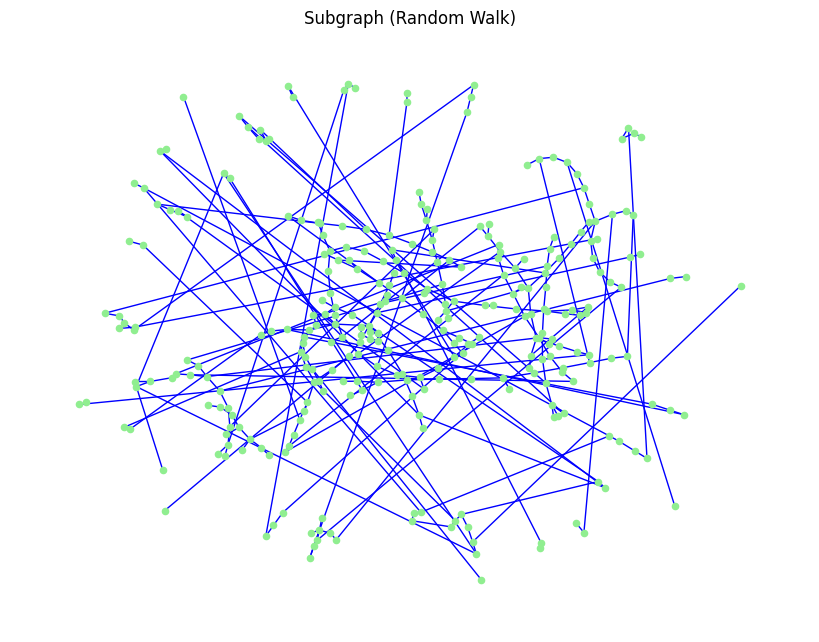

In [70]:
G_sub = G.subgraph(walk)
pos = nx.spring_layout(G_sub, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G_sub, pos, node_color='lightgreen', node_size=20, edge_color='blue')
plt.title("Subgraph (Random Walk)")
plt.show()

In [71]:
# Create an empty pandapower network
sub_net = pp.create_empty_network(sn_mva=net.sn_mva)

# Copy only the buses in the walk
node_mapping = {}
for bus in walk:
    bus_data = net.bus.loc[bus]
    new_bus = pp.create_bus(sub_net, **bus_data)
    node_mapping[bus] = new_bus

In [72]:
net.bus.head()

,name,vn_kv,type,zone,in_service,min_vm_pu,max_vm_pu
0,NaN,345.0,b,1.0,True,0.9,1.1
1,NaN,345.0,b,1.0,True,0.9,1.1
2,NaN,345.0,b,1.0,True,0.9,1.1
3,NaN,345.0,b,1.0,True,0.9,1.1
4,NaN,345.0,b,1.0,True,0.9,1.1


In [73]:
sub_net.bus.head()

,name,vn_kv,type,zone,in_service,min_vm_pu,max_vm_pu
0,NaN,69.0,b,1.0,True,0.9,1.1
1,NaN,69.0,b,1.0,True,0.9,1.1
2,NaN,69.0,b,1.0,True,0.9,1.1
3,NaN,69.0,b,1.0,True,0.9,1.1
4,NaN,138.0,b,1.0,True,0.9,1.1


In [74]:
elements = ['load', 'sgen', 'gen', 'storage', 'shunt']

for el in elements:
    for idx, row in net[el].iterrows():
        if row['bus'] in node_mapping:
            data = row.drop(labels=['name'], errors='ignore').to_dict()
            data['bus'] = node_mapping[row['bus']]
            new_idx = getattr(pp, f"create_{el}")(sub_net, **data)

            if el in ['gen', 'sgen']:
                cost_row = net.poly_cost[(net.poly_cost['element'] == idx) & (net.poly_cost['et'] == el)]
                if not cost_row.empty:
                    for _, cost in cost_row.iterrows():
                        cost_data = cost.drop(labels=["element", "et"]).to_dict()
                        pp.create_poly_cost(
                            sub_net,
                            element=new_idx,
                            et=el,
                            **cost_data
                        )

In [75]:
net.line.head()

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,max_loading_percent
0,NaN,NaN,0,749,1.0,2.625692,29.263486,620.868080,0.0,1.231681,1.0,1,ol,True,100.0
1,NaN,NaN,0,873,1.0,0.163064,2.766141,135.025971,0.0,3.141120,1.0,1,ol,True,100.0
2,NaN,NaN,1,294,1.0,0.430871,6.077416,220.550442,0.0,2.185564,1.0,1,ol,True,100.0
3,NaN,NaN,1,688,1.0,0.030946,0.391592,15.377289,0.0,2.093522,1.0,1,ol,True,100.0
4,NaN,NaN,2,5,1.0,0.003571,0.058322,2.139449,0.0,2.374667,1.0,1,ol,True,100.0


In [76]:
for _, row in net.line.iterrows():
    if row.from_bus in node_mapping and row.to_bus in node_mapping:
        line_data = row.drop(labels=["from_bus", "to_bus", "std_type"]).to_dict()
        pp.create_line_from_parameters(
            sub_net,
            from_bus=node_mapping[row.from_bus],
            to_bus=node_mapping[row.to_bus],
            **line_data
        )

In [77]:
net.line.head()

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,max_loading_percent
0,NaN,NaN,0,749,1.0,2.625692,29.263486,620.868080,0.0,1.231681,1.0,1,ol,True,100.0
1,NaN,NaN,0,873,1.0,0.163064,2.766141,135.025971,0.0,3.141120,1.0,1,ol,True,100.0
2,NaN,NaN,1,294,1.0,0.430871,6.077416,220.550442,0.0,2.185564,1.0,1,ol,True,100.0
3,NaN,NaN,1,688,1.0,0.030946,0.391592,15.377289,0.0,2.093522,1.0,1,ol,True,100.0
4,NaN,NaN,2,5,1.0,0.003571,0.058322,2.139449,0.0,2.374667,1.0,1,ol,True,100.0


In [78]:
sub_net.line.head()

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,max_loading_percent
0,NaN,None,60,55,1.0,1.272500,16.455000,535.168045,0.0,1.991858,1.0,1,ol,True,100.0
1,NaN,None,60,62,1.0,3.357500,42.022500,1473.520125,0.0,1.991858,1.0,1,ol,True,100.0
2,NaN,None,52,53,1.0,0.370300,4.329336,172.332611,0.0,1.993114,1.0,1,ol,True,100.0
3,NaN,None,57,56,1.0,0.052181,0.153685,3.175745,0.0,0.535513,1.0,1,ol,True,100.0
4,NaN,None,41,34,1.0,2.021806,5.197584,112.989647,0.0,0.493676,1.0,1,ol,True,100.0


In [79]:
for _, row in net.trafo.iterrows():
    if row.hv_bus in node_mapping and row.lv_bus in node_mapping:
        trafo_data = row.drop(labels=["hv_bus", "lv_bus"]).to_dict()
        pp.create_transformer_from_parameters(
            sub_net,
            hv_bus=node_mapping[row.hv_bus],
            lv_bus=node_mapping[row.lv_bus],
            **trafo_data
        )

In [80]:
sub_net

This pandapower network includes the following parameter tables:
   - bus (300 elements)
   - load (203 elements)
   - sgen (23 elements)
   - gen (12 elements)
   - line (262 elements)
   - trafo (126 elements)
   - poly_cost (35 elements)

In [81]:
slack_bus = pp.create_bus(sub_net, vn_kv=net.bus.loc[walk[0]].vn_kv, name="VirtualSlack")
pp.create_ext_grid(sub_net, bus=slack_bus, vm_pu=1.0, name="VirtualSlack")

0

In [82]:
# Add border lines (edges between walk and outside)
border_lines = []
for idx, row in net.line.iterrows():
    in_walk = row.from_bus in walk
    out_walk = row.to_bus in walk
    if in_walk != out_walk:
        border_lines.append((idx, row))

print(f"{len(border_lines)} border lines will be reconnected to Slack.")

146 border lines will be reconnected to Slack.


In [83]:
# For each border line, connect from inside to the new slack
for idx, row in border_lines:
    if row.from_bus in node_mapping:
        from_bus = node_mapping[row.from_bus]
        to_bus = slack_bus
    else:
        from_bus = slack_bus
        to_bus = node_mapping[row.to_bus]

    line_data = row.drop(labels=["from_bus", "to_bus", "std_type"]).to_dict()

    pp.create_line_from_parameters(
        sub_net,
        from_bus=from_bus,
        to_bus=to_bus,
        **line_data
    )

In [88]:
pp.runopp(sub_net)

OPFNotConverged: Optimal Power Flow did not converge!

In [85]:
sub_net

This pandapower network includes the following parameter tables:
   - bus (301 elements)
   - load (203 elements)
   - sgen (23 elements)
   - gen (12 elements)
   - ext_grid (1 element)
   - line (408 elements)
   - trafo (126 elements)
   - poly_cost (35 elements)
 and the following results tables:
   - res_bus (301 elements)
   - res_line (408 elements)
   - res_trafo (126 elements)
   - res_ext_grid (1 element)
   - res_load (203 elements)
   - res_sgen (23 elements)
   - res_gen (12 elements)

Note that the load stays the same as before, it is not modified during OPF, only the generation dispatch is changed

In [86]:
# assert that the load doesnt get changed
assert sub_net.res_load.p_mw.equals(sub_net.load.p_mw)
assert sub_net.res_load.q_mvar.equals(sub_net.load.q_mvar)


we can check if the constraints on the active and reactive power are respected:

In [87]:
# check active power is less than the upper bound
assert (
    sub_net.gen.max_p_mw - sub_net.res_gen.p_mw > -1e-4
).all(), "upper bound on active power is violated"
# check active power is more than the lower bound
assert (
    sub_net.res_gen.p_mw - sub_net.gen.min_p_mw
).all(), "lower bound on active power is violated"

# same for reactive power
assert (
    sub_net.gen.max_q_mvar - sub_net.res_gen.q_mvar > -1e-4
).all(), "upper bound on reactive power is violated"

assert  (
    sub_net.res_gen.q_mvar - sub_net.gen.min_q_mvar
).all(),  "lower bound on reactive power is violated"

AssertionError: lower bound on active power is violated

## Checking power balance

We can check that some other basic constraints are satisfied. For example, the total power generated should be equal to the total power consumed + loss

- We sum the active and reactive power of all generator elements (gen, static gen and slack) connected to each bus:

In [ ]:
all_gens = (
    pd.concat([sub_net.res_gen, sub_net.res_sgen, sub_net.res_ext_grid])[["p_mw", "q_mvar"]]
    .sum()
)
all_gens

p_mw      4840.272226
q_mvar   -1542.080746
dtype: float64

- total generation across all buses:

- We can now sum the active and reactive power of all load elements (loads, shunts and transformers) + losses (line and transformer):

In [ ]:
all_consumption_p_mw = (
    sub_net.res_load.p_mw.sum()
    + sub_net.res_line.pl_mw.sum()
    + sub_net.res_trafo.pl_mw.sum()
    + sub_net.res_shunt.p_mw.sum()
)  # active
all_consumption_p_mw

all_consumption_q_mvar = (
    sub_net.res_load.q_mvar.sum()
    + sub_net.res_line.ql_mvar.sum()
    + sub_net.res_trafo.ql_mvar.sum()
    + sub_net.res_shunt.q_mvar.sum()
)  # reactive
all_consumption_q_mvar



print(f"Total active consumption: {all_consumption_p_mw} MW")
print(f"Total reactive consumption: {all_consumption_q_mvar} MVar")
print(all_gens)

Total active consumption: 4840.2722870511125 MW
Total reactive consumption: -1542.080557363664 MVar
p_mw      4840.272226
q_mvar   -1542.080746
dtype: float64


- The total load + losses matches the total generation!

## res bus

Note that the net power demand is also available in the `res_bus` table.

To check that, we can compute the net power consumption at each bus (i.e. all loads - all geneation)

In [ ]:
all_loads = (
    pd.concat([sub_net.res_load, sub_net.res_shunt])[["p_mw", "q_mvar"]]
    .sum()
)  # all load
net_consumption = (
    pd.concat([all_loads, -all_gens])
    .sum()
)  # net load = load - generation

and check that the net power consumption is equal to the data in the `res_bus` table

In [ ]:
net_consumption

1168.2070679368917

In [ ]:
import numpy as np
assert np.allclose(sub_net.res_bus[["p_mw", "q_mvar"]], net_consumption)

AssertionError: 

# Power flow

After solving OPF, we solve PF to get a "full snapshot" of our grid.
When solving PF, the following variables are fixed and we solve for the rest:

| **Bus Type**    | **Fixed Variables**                    | **Solved Variables**                    |
|------------------|----------------------------------------|------------------------------------------|
| **Slack (REF)** | `vm_pu` (voltage magnitude), `va_degree` (voltage angle) | `p_mw` (active power), `q_mvar` (reactive power) |
| **PV** | `p_mw` (active power), `vm_pu` (voltage magnitude) | `q_mvar` (reactive power), `va_degree` (voltage angle) |
| **PQ**    | `p_mw` (active power), `q_mvar` (reactive power) | `vm_pu` (voltage magnitude), `va_degree` (voltage angle) |



## Setting the active power and voltage magnitude of generators based on results of OPF 

For pandapower to run PF on the OPF solutions, we need to copy OPF results of OPF from the `res_gen` and `res_sgen` tables to the `gen` and `sgen` tables.
- Among the fixed variables (see table above), only `p_mw` and `vm_pu` at PV nodes got changed after running OPF and thus require us to copy their new values. Note that the `p_mw` and `q_mvar` at PQ nodes did not get changed during OPF (they are in fact the input of OPF), and that the slack voltage magnitude and angle at slack nodes are fixed parameters that can not change.
- Thus, we only set the real power `p_mw` and voltage `vm_pu` at `gen` and `sgen` elements



In [ ]:
net.gen[["p_mw", "vm_pu"]] = net.res_gen[["p_mw", "vm_pu"]]

In [ ]:
net.sgen["p_mw"] = net.res_sgen["p_mw"] # note that there is no voltage info at sgens, since they do not participate in the voltage control

- Note that there is no need to set the `shunt`s' power or the `ext_grid`'s power, as they are computed during the power flow (PF) calculation.
- Their purpose is precisely to correct slight mismatches in power generation and demand by generating or consuming some energy.


## <p style="color:red"> TO DO: Adding small perturbations to the OPF results </p>




Note that this is where we could add small "perturbations" to the `p_mw` and `vm_pu` of `gen`s and `sgen`s obtained from the OPF solutions we obtained, to generate many "suboptimal" generation dispatch from our single OPF solution.

For now, we contiune with the OPF solution.



## Run PF

- We run powerflow using the `runpp` function from pandapower
- This overwrites the res_tables with the PF results.

In [ ]:
pp.runpp(net)

we can access the PF solutions using the `net.res_*` tables